<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>

# **Bootstrap Aggregating (Bagging) for classification**

## **Introduction**

**Bagging**, short for **bootstrap aggregating**, is an ensemble method. It trains many versions of a model and combines their predictions into one final prediction.

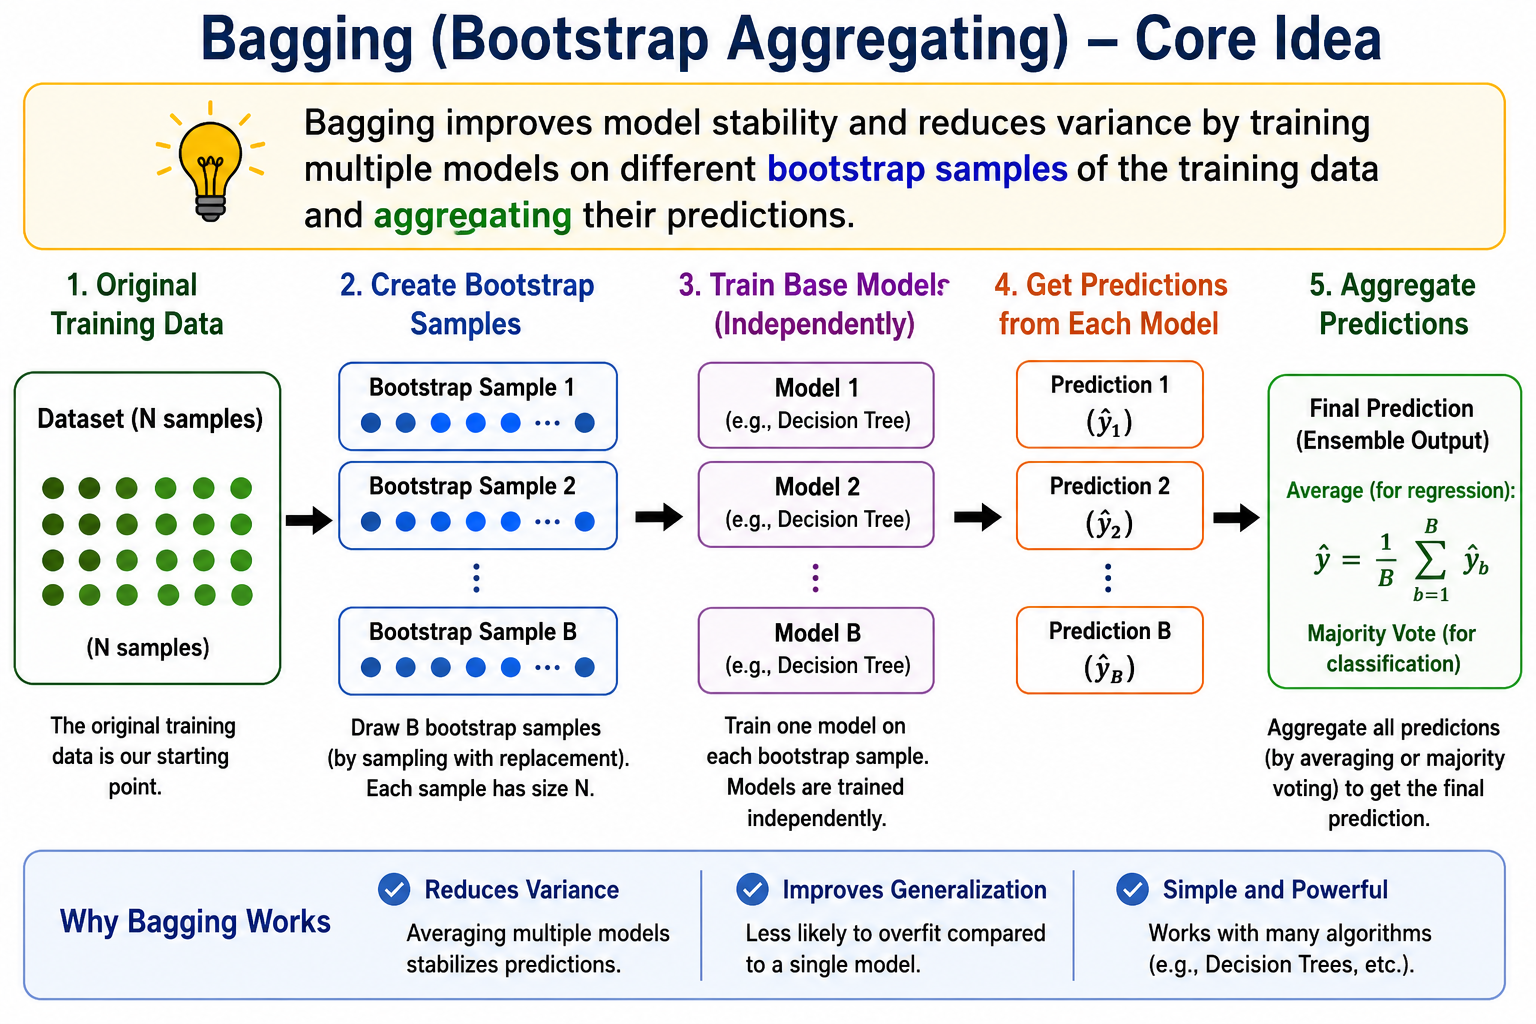

The image above shows the bagging process. We start with the original training data, create many bootstrap samples by sampling rows with replacement, train one base model on each sample, collect predictions from all models, and aggregate those predictions.

For classification, bagging usually combines predictions by majority vote:

$$
\hat{y} = \text{mode}(h_1(x), h_2(x), ..., h_B(x))
$$

Here, $h_b(x)$ is the prediction from model $b$, and $B$ is the total number of models.

For regression, bagging usually averages the base model predictions. In both cases, the main benefit is stability. Training many models on different bootstrap samples reduces variance and makes the final prediction less sensitive to small changes in the training data.

`BaggingClassifier` does not use one special loss function for the whole ensemble. Each base model uses its own training loss or split criterion. Bagging mainly helps by reducing variance, especially for unstable models such as decision trees.

Random Forest also uses bagging ideas, but it is designed specifically for decision trees. It trains many trees on bootstrap samples and also selects a random subset of features at each split.

`BaggingClassifier` is more general. It can apply bagging to different base classifiers, such as decision trees, SVM models, KNN models, or other classifiers.

In short, use **Random Forest** when you want a strong tree-based ensemble. Use **BaggingClassifier** when you want to apply bagging to another type of classifier or compare bagging across different models.


In this notebook, we will first review bootstrap sampling and model instability. Then we will use `BaggingClassifier` to train an ensemble model and compare when bagging helps versus when it has little effect.


### **Training and Evaluation with scikit-learn**

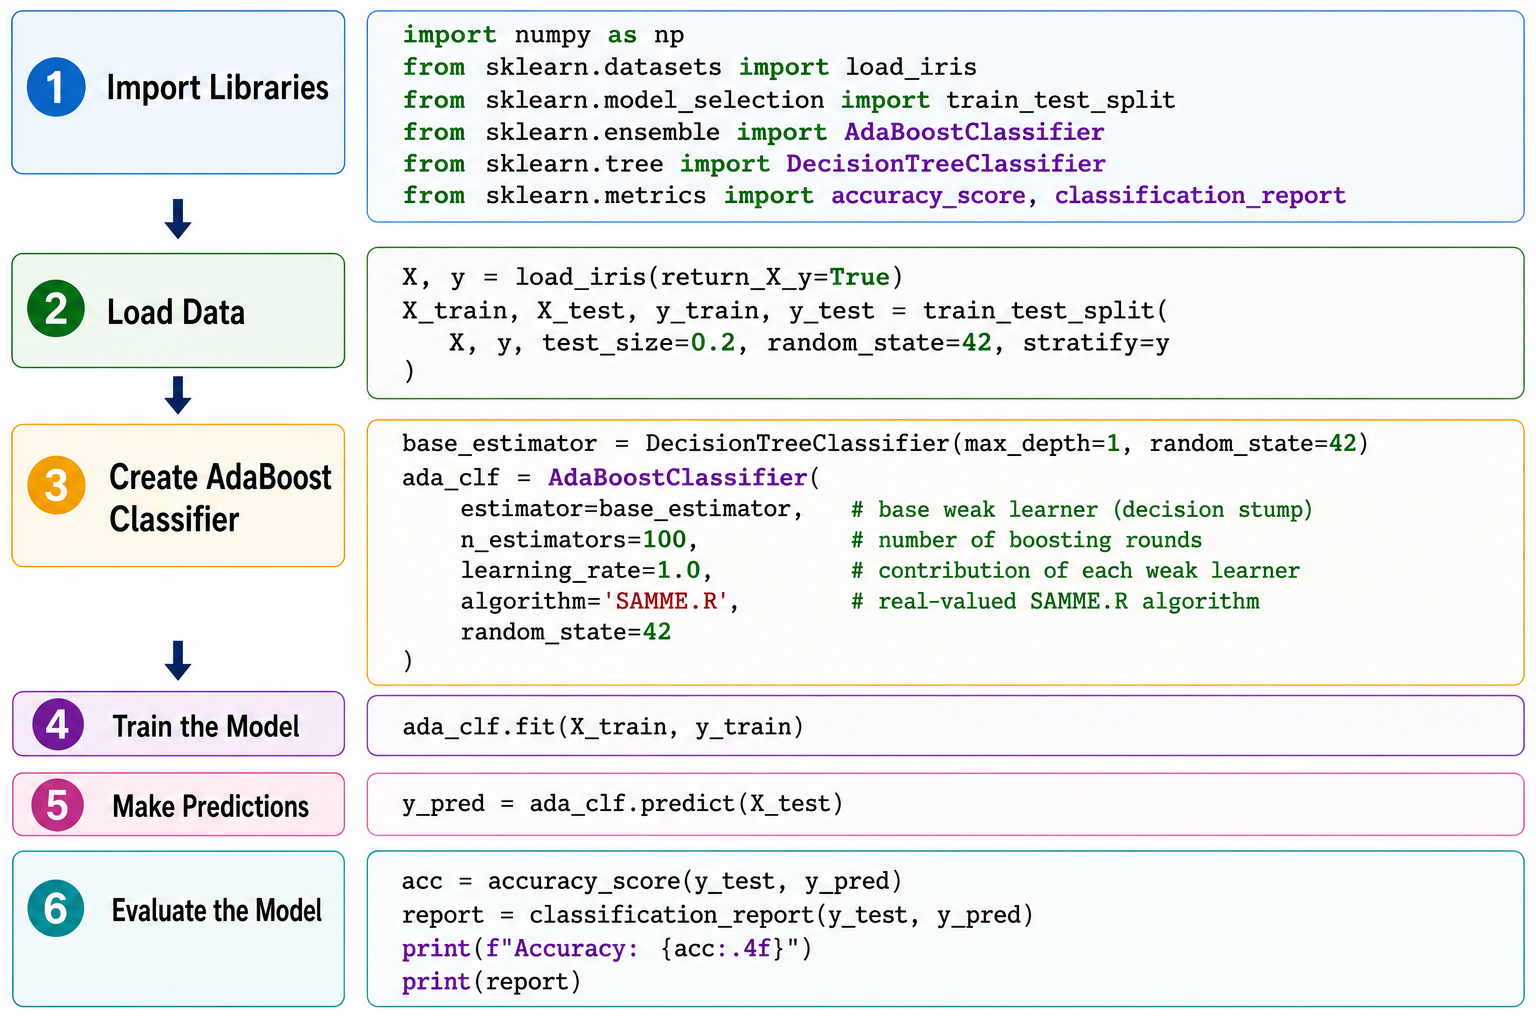

The image above shows a general scikit-learn workflow for training and evaluating an ensemble classifier. The steps are to import libraries, load and split the data, create the ensemble model, train it, make predictions, and evaluate the results.

In this lab, we apply this same workflow to `BaggingClassifier`. The base estimator can be a decision tree or another classifier. After training, we evaluate the bagging model with metrics such as accuracy and a classification report.


## **Objectives**

A telecommunications company wants to understand why some customers are leaving its land-line service for cable competitors. We will use a telecommunications dataset to predict **customer churn**.

After completing this lab, you will be able to:

* Understand bootstrap sampling.
* Explain why bagging can reduce variance.
* Explain model instability.
* Apply `BaggingClassifier`.
* Identify when bagging is useful.


## **Workflow**
### **Setup**


Let's first import required libraries:


In [194]:
# Core libraries
import warnings
from io import StringIO

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydotplus
import seaborn as sns
%matplotlib inline

# Scikit-learn helpers, models, and evaluation tools
from sklearn import metrics, preprocessing, tree
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils import resample

# Give loops a progress bar
from tqdm import tqdm

warnings.filterwarnings("ignore", category=DeprecationWarning)

rs = 0


This function calculates the train and test accuracy of a model


In [ ]:
def get_accuracy(X_train, X_test, y_train, y_test, model):
    return {
        "test Accuracy": metrics.accuracy_score(y_test, model.predict(X_test)),
        "train Accuracy": metrics.accuracy_score(
            y_train, model.predict(X_train)
        ),
    }

This function creates visualizations of decision trees


In [ ]:
# Plot tree helper libraries
from io import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree


def plot_tree(model, filename="tree.png"):
    # global churn_df

    dot_data = StringIO()

    featureNames = [
        colunm
        for colunm in churn_df[
            ["tenure", "age", "address", "income", "ed", "employ", "equip"]
        ].columns
    ]
    out = tree.export_graphviz(
        model,
        feature_names=featureNames,
        out_file=dot_data,
        class_names=["left", "stay"],
        filled=True,
        special_characters=True,
        rotate=False,
    )
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    graph.write_png(filename)
    img = mpimg.imread(filename)
    plt.figure(figsize=(100, 200))
    plt.imshow(img, interpolation="nearest")

This function creates a graph of training accuracy vs how many estimators (Decision Trees) a BaggingClassifier uses


In [ ]:
def get_accuracy_bag(X, y, title, times=20, xlabel="Number Estimators"):
    # Iterate through different number of estimators and average out the results

    N_estimators = [n for n in range(1, 70)]
    times = 20
    train_acc = np.zeros((times, len(N_estimators)))
    test_acc = np.zeros((times, len(N_estimators)))

    train_time = np.zeros((times, len(N_estimators)))
    test_time = np.zeros((times, len(N_estimators)))
    # average out the results
    for n in tqdm(range(times)):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, stratify=y
        )
        for n_estimators in N_estimators:
            # Iterate through different number of estimators and average out the results

            Bag = BaggingClassifier(
                estimator=DecisionTreeClassifier(
                    criterion="entropy", max_depth=10
                ),
                n_estimators=n_estimators,
                bootstrap=True,
                random_state=0,
            )
            Bag.fit(X_train, y_train)

            Accuracy = get_accuracy(X_train, X_test, y_train, y_test, Bag)

            train_acc[n, n_estimators - 1] = Accuracy["train Accuracy"]
            test_acc[n, n_estimators - 1] = Accuracy["test Accuracy"]

    fig, ax1 = plt.subplots()

    ax2 = ax1.twinx()
    ax1.plot(train_acc.mean(axis=0))
    ax2.plot(test_acc.mean(axis=0), c="r")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Training accuracy", color="b")
    ax2.set_ylabel("Testing accuracy", color="r")
    plt.title(title)
    plt.show()

### **Customer Data Example**

#### **About the dataset**

The same customer churn dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.4.


#### **Load Data From CSV File**


In [ ]:
churn_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
)

churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


#### **Data pre-processing and selection**


Let's select some features for the modeling. Also, we change the target data type to be an integer, as it is a requirement by the skitlearn algorithm:


In [ ]:
churn_df = churn_df[
    [
        "tenure",
        "age",
        "address",
        "income",
        "ed",
        "employ",
        "equip",
        "callcard",
        "wireless",
        "churn",
    ]
]
churn_df["churn"] = churn_df["churn"].astype("int")
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


#### **Exercise**

How many rows and columns are in this dataset in total? What are the names of columns?


In [200]:
# write your code here
print(churn_df.shape)

print(churn_df.columns)

(200, 10)
Index(['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',
       'callcard', 'wireless', 'churn'],
      dtype='object')


#### **Bootstrap Sampling**

Bootstrap Sampling is a method that involves drawing of sample data repeatedly with replacement from a data source to estimate a model parameter. Scikit-learn has methods for Bagging but its helpful to understand Bootstrap sampling.  We will import <code>resample</code>


In [201]:
from sklearn.utils import resample

Consider the five rows of data:


In [202]:
churn_df[0:5]

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


We can perform a bootstrap sample using the function <code>resample</code>; we see the dataset is the same size, but some rows are repeated:


In [203]:
resample(churn_df[0:5])

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1


We can repeat the process randomly drawing several other rows


In [204]:
resample(churn_df[0:5])

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0


#### **Train/Test dataset**


Let's define X, and y for our dataset:


In [ ]:
X = churn_df[["tenure", "age", "address", "income", "ed", "employ", "equip"]]

X.head()

,tenure,age,address,income,ed,employ,equip
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0


In [ ]:
y = churn_df["churn"]
y.head()

0    1
1    1
2    0
3    0
4    0
Name: churn, dtype: int64

We split our dataset into train and test set:


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)
print("Train set", X_train.shape, y_train.shape)
print("Test set", X_test.shape, y_test.shape)

Train set (140, 7) (140,)
Test set (60, 7) (60,)


#### **Decision Tree Classifier with Scikit-learn**


A Decision  tree Classifier classifies a sample by learning simple decision rules inferred from the data. One problem with Decision  Tree Classifiers is overfitting; they do well with the training data, but they do not Generalize well. Trees have low bias and high variance; as such, they are a prime candidate for Bagging. Instability is another term used to describe models that overfit. Instability is characterized by a slight change in the training set that causes a drastic change in the model.  Let's show that Decision tree Classifiers are unstable.


Let's load the DecisionTreeClassifier modle in   <coode>sklearn</code>


In [208]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

We create and train a tree with a max depth of  5


In [ ]:
max_depth = 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=10
)
Tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=max_depth, random_state=10
)
Tree
Tree.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Now we can predict using our test set:


In [210]:
yhat = Tree.predict(X_test)
yhat

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

We see the test error is much larger than the training error:


In [ ]:
get_accuracy(X_train, X_test, y_train, y_test, Tree)

{'test Accuracy': 0.6666666666666666, 'train Accuracy': 0.8285714285714286}

We can plot the nodes of the tree:


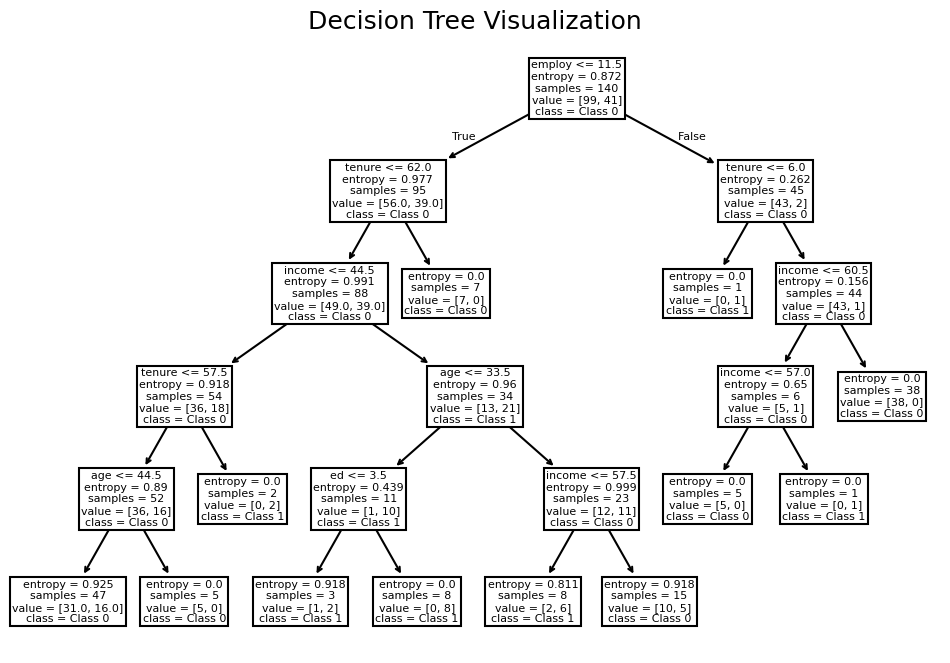

In [ ]:
# Adjust the tree plot without 'filled' argument if necessary
plt.figure(figsize=(12, 8))
plot_tree(
    Tree,
    feature_names=X.columns,  # Make sure this is a DataFrame; replace with list if it's not
    class_names=["Class 0", "Class 1"],
)  # Replace with actual class names

plt.title("Decision Tree Visualization")
# plt.savefig("tree.png")
plt.show()

We can repeat the process but sampling different data points from the same dataset.  We see the tree still suffers from overfitting; in addition, the new tree is entirely different.


{'test Accuracy': 0.6666666666666666, 'train Accuracy': 0.85}


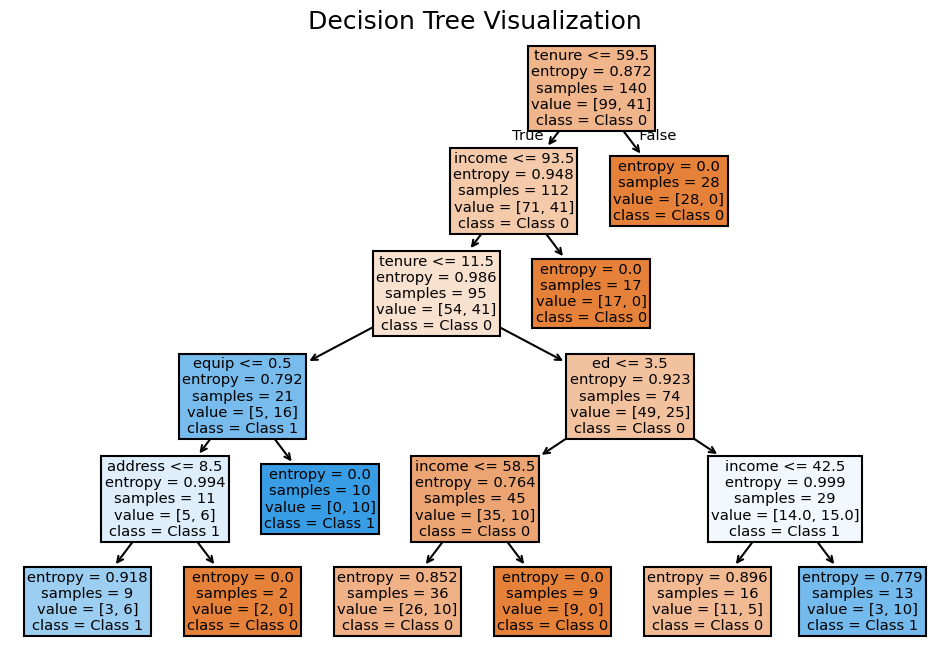

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=5
)
Tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=max_depth, random_state=8
)
Tree.fit(X_train, y_train)
print(get_accuracy(X_train, X_test, y_train, y_test, Tree))
plt.figure(figsize=(12, 8))  # Set figure size
plot_tree(
    Tree,
    filled=True,
    feature_names=X.columns,  # Replace with actual feature names if X is not a DataFrame
    class_names=["Class 0", "Class 1"],
)  # Replace with actual class names

# Save the tree as an image
plt.title("Decision Tree Visualization")
# plt.savefig("tree1.png")
plt.show()

#### **Bagging for classification**
A Bagging classifier is an ensemble model that trains  base classifiers  on random subsets   of the original dataset  (Bootstrap Sampling by default), and then aggregate their individual predictions by voting. We import the module:


In [214]:
from sklearn.ensemble import BaggingClassifier

Bagging improves models that suffer from overfitting; they do well on the training data, but they do not Generalize well. Decision Trees are a prime candidate for this reason, in addition, they are fast to train; We create a <code>BaggingClassifier</code> object,  with a Decision Tree as the <code>estimator</code>


In [ ]:
Bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy", max_depth=4, random_state=2
    ),
    n_estimators=30,
    random_state=0,
    bootstrap=True,
)

We fit the model:


In [ ]:
Bag.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=2)
,n_estimators,30
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,0
,verbose,0


The method <code>predict</code>  aggregates the predictions by voting:


In [217]:
Bag.predict(X_test)

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0])

We see the training accuracy is slightly better but the test accuracy improves  dramatically:


In [ ]:
print(get_accuracy(X_train, X_test, y_train, y_test, Bag))

{'test Accuracy': 0.7, 'train Accuracy': 0.8857142857142857}


Here we can see the impact of adding more estimators (Decision Trees) using in Bagging on the testing and training accuracy


100%|██████████| 20/20 [00:43<00:00,  2.16s/it]


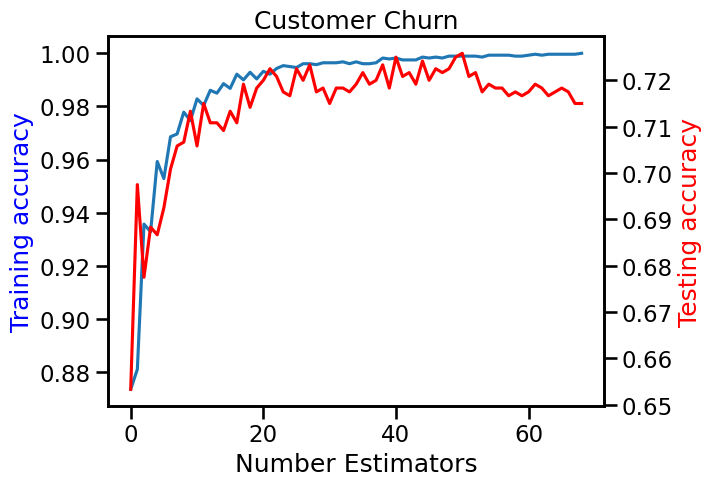

In [221]:
get_accuracy_bag(X, y, "Customer Churn")

#### **Evaluation**

Evaluate the Bagging model using a confusion matrix, ROC curve, and precision-recall curve.


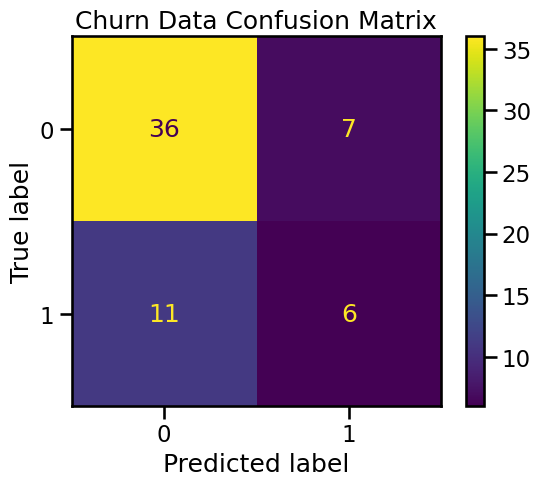

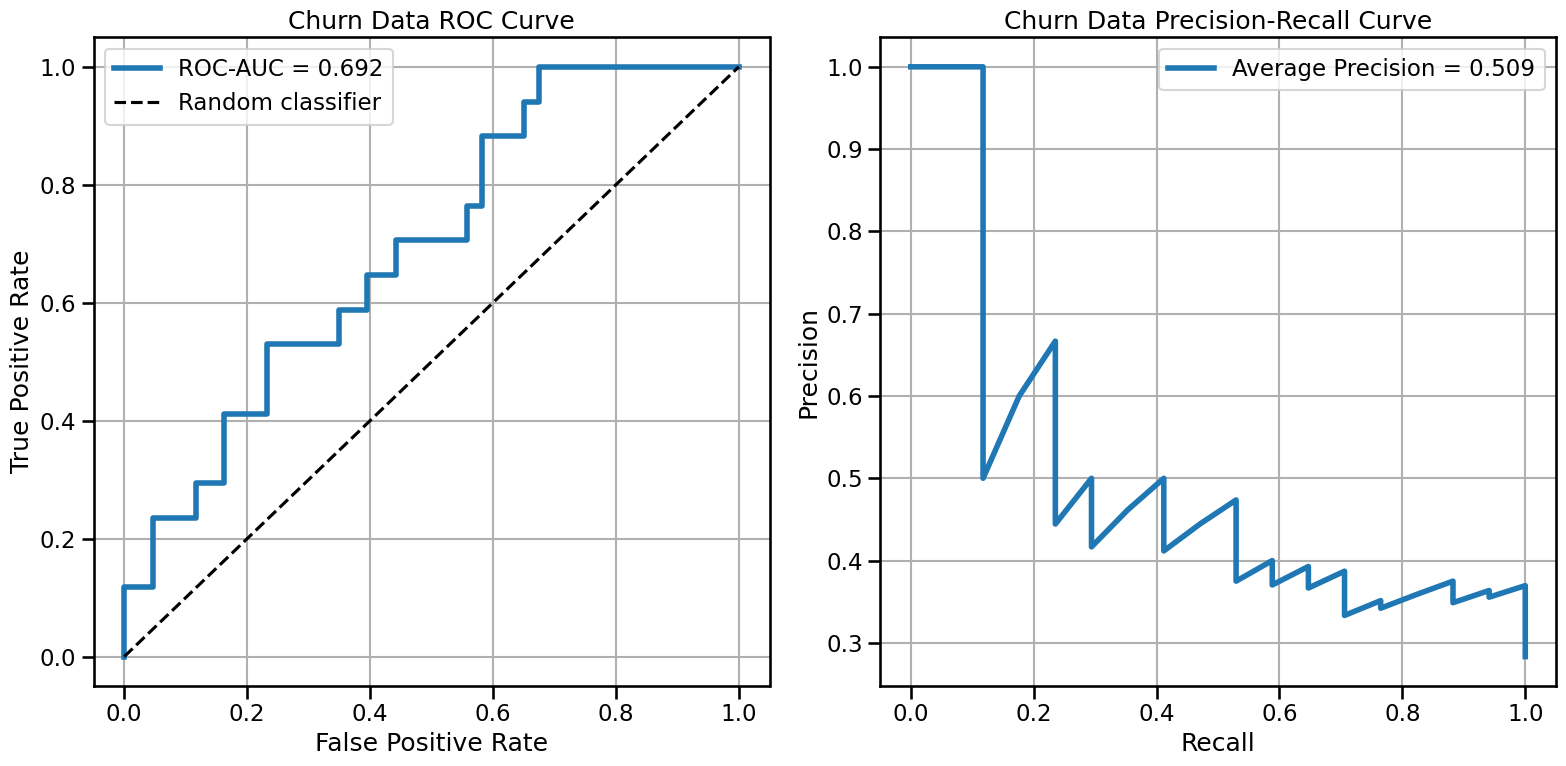

In [ ]:
bag_churn = Bag
y_pred = bag_churn.predict(X_test)

sns.set_context("talk")
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=bag_churn.classes_
)
disp.plot()
plt.title("Churn Data Confusion Matrix")
plt.show()

# ROC and precision-recall curves for class 1.
y_score = bag_churn.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

fpr, tpr, _ = metrics.roc_curve(y_test, y_score)
roc_auc = metrics.roc_auc_score(y_test, y_score)
axes[0].plot(fpr, tpr, linewidth=4, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot(
    [0, 1], [0, 1], linestyle="--", color="black", label="Random classifier"
)
axes[0].set(
    title="Churn Data ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
axes[0].legend()
axes[0].grid(True)

precision, recall, _ = metrics.precision_recall_curve(y_test, y_score)
avg_precision = metrics.average_precision_score(y_test, y_score)
axes[1].plot(
    recall,
    precision,
    linewidth=4,
    label=f"Average Precision = {avg_precision:.3f}",
)
axes[1].set(
    title="Churn Data Precision-Recall Curve",
    xlabel="Recall",
    ylabel="Precision",
)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Findings:**

The Bagging model reaches **0.70 test accuracy** and **0.886 training accuracy**. This is slightly better than the single decision tree test accuracy of about **0.67**, but the training score is still much higher than the test score, so the model still shows some overfitting. In the confusion matrix, the model correctly predicts many non-churn customers but misses several churn customers. This means churn recall is still limited, which is important because the business goal is to identify customers who may leave.


#### **Feature Importance**

Average the feature importances across all decision trees in the Bagging model.


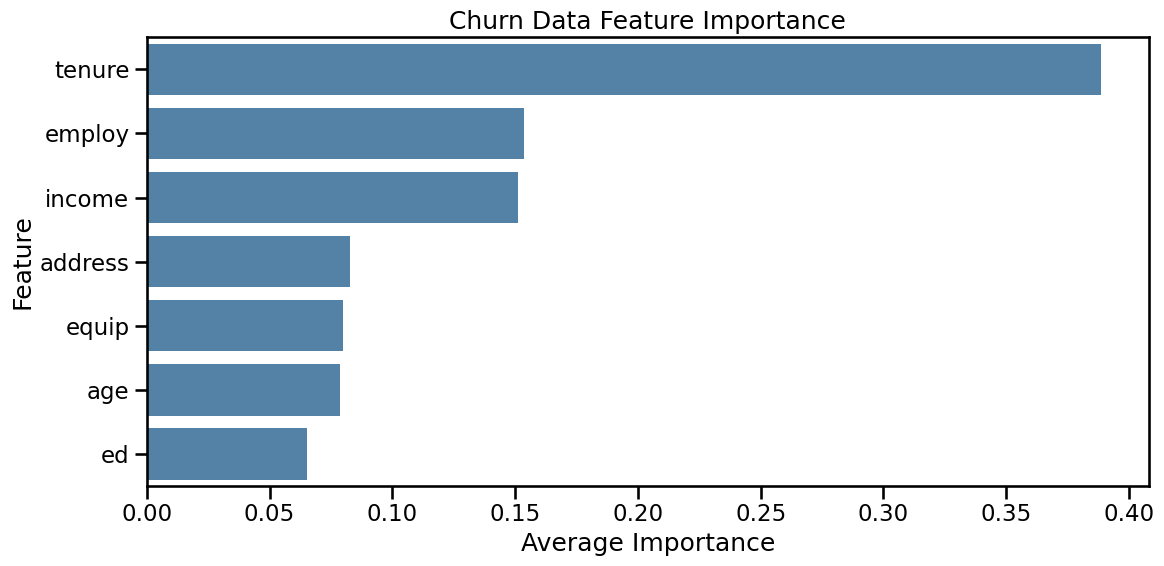

In [ ]:
feature_imp = np.mean(
    [tree.feature_importances_ for tree in bag_churn.estimators_], axis=0
)

feature_imp = pd.Series(feature_imp, index=X_train.columns).sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color="steelblue")
ax.set(
    title="Churn Data Feature Importance",
    xlabel="Average Importance",
    ylabel="Feature",
)
plt.tight_layout()
plt.show()

**Findings:**

The most important churn feature is **tenure**, which has the largest importance score by a clear margin. **Employment length** and **income** are the next most important features. This suggests the Bagging model relies most on how long a customer has stayed, their work history, and their income level when predicting churn.


#### **Low Variance Example**


Bagging usually does not help much when the base model already has low variance. In other words, if the model performs similarly on the training data and the test data, its predictions are already stable. For example, an **SVM** may have similar accuracy on both the training and test sets, so bagging may not improve its performance much.







In [ ]:
from sklearn.svm import SVC

clf = SVC(kernel="linear", gamma="scale")
clf.fit(X_train, y_train)
print(get_accuracy(X_train, X_test, y_train, y_test, clf))

{'test Accuracy': 0.7, 'train Accuracy': 0.7714285714285715}


Bagging the SVM does almost nothing:


In [ ]:
Bag = BaggingClassifier(
    estimator=SVC(kernel="linear", gamma="scale"),
    n_estimators=10,
    random_state=0,
    bootstrap=True,
)
Bag.fit(X_train, y_train)
print(get_accuracy(X_train, X_test, y_train, y_test, Bag))

{'test Accuracy': 0.6666666666666666, 'train Accuracy': 0.7714285714285715}


### **Cancer Data Example**

The same cancer dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.4.

Let's load the dataset:


In [ ]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/cell_samples.csv"
)

df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Now lets remove rows that have a ? in the `BareNuc` column


In [225]:
df = df[df["BareNuc"] != "?"]

Now lets define the X and y for our dataset


In [ ]:
X = df[
    [
        "Clump",
        "UnifSize",
        "UnifShape",
        "MargAdh",
        "SingEpiSize",
        "BareNuc",
        "BlandChrom",
        "NormNucl",
        "Mit",
    ]
]

X.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1


In [ ]:
y = df["Class"]

y.head()

0    2
1    2
2    2
3    2
4    2
Name: Class, dtype: int64

Now lets split our data into training and testing data with a 80/20 split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=4
)
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)


Now to determine the best parameters for `n_estimators` and the `max_depth` of the `estimator` we will use `GridSearchCV`


In [229]:
from sklearn.model_selection import GridSearchCV

We can use GridSearch for Exhaustive search over specified parameter values. To  alter the base  model; we add the double underscore and the attribute value:

Here we are searching odd numbers from 1 to 39 for `n_estimators` and odd numbers from 1 to 20 for `max_depth` in the `estimator`


In [ ]:
param_grid = {
    "n_estimators": [2 * n + 1 for n in range(20)],
    "estimator__max_depth": [2 * n + 1 for n in range(10)],
}

Create a `BaggingClassifier` object called `Bag` with the `estimator` set to a `DecisionTreeClassifier` object where `random_state` = 0 and `bootstrap` = True


In [ ]:
Bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(), random_state=0, bootstrap=True
)

Now we create a `GridSearchCV` object and search for the best parameters according to our `parameter_grid`. Because this is a classification task, we use `StratifiedKFold` for cross-validation. It keeps the class proportions similar in each fold, and `shuffle=True` randomizes the data before creating the folds.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

search = GridSearchCV(
    estimator=Bag, param_grid=param_grid, scoring="accuracy", cv=cv
)

In [233]:
search.fit(X_train, y_train)

,estimator,BaggingClassi...andom_state=0)
,param_grid,"{'estimator__max_depth': [1, 3, ...], 'n_estimators': [1, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


We can see the best accuracy score of the searched parameters was ~97%


In [234]:
search.best_score_

0.9706755629691409

We can also see the parameters that resulted in the best score


In [235]:
search.best_params_

{'estimator__max_depth': 5, 'n_estimators': 39}

And we can see the testing and training accuracy of the best estimator


In [236]:
print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 0.948905109489051, 'train Accuracy': 0.9945054945054945}


Below we can see a graph of testing and training accuracy holding the `max_depth` of the `estimator` at 10 and varying the number of estimators. We can see that it is extremely close to the accuracy of the `best_estimator` we found using `GridSearchCV`


100%|██████████| 20/20 [00:39<00:00,  1.97s/it]


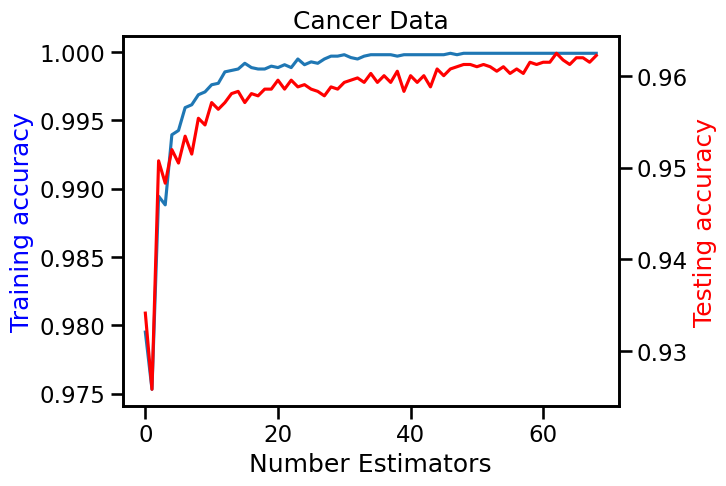

In [239]:
get_accuracy_bag(X, y, "Cancer Data")

#### **Evaluation**

Evaluate the best Bagging model from GridSearchCV using a confusion matrix, ROC curve, and precision-recall curve.


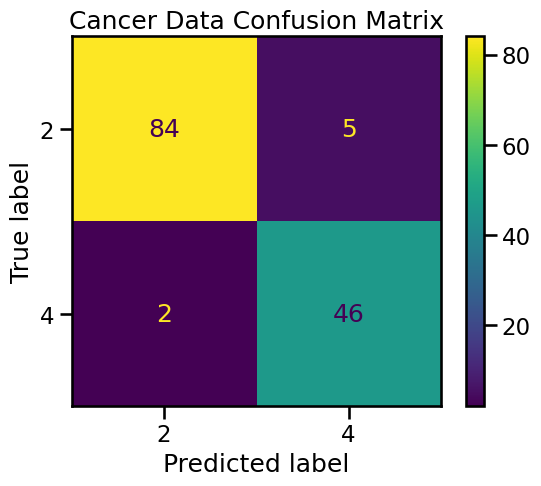

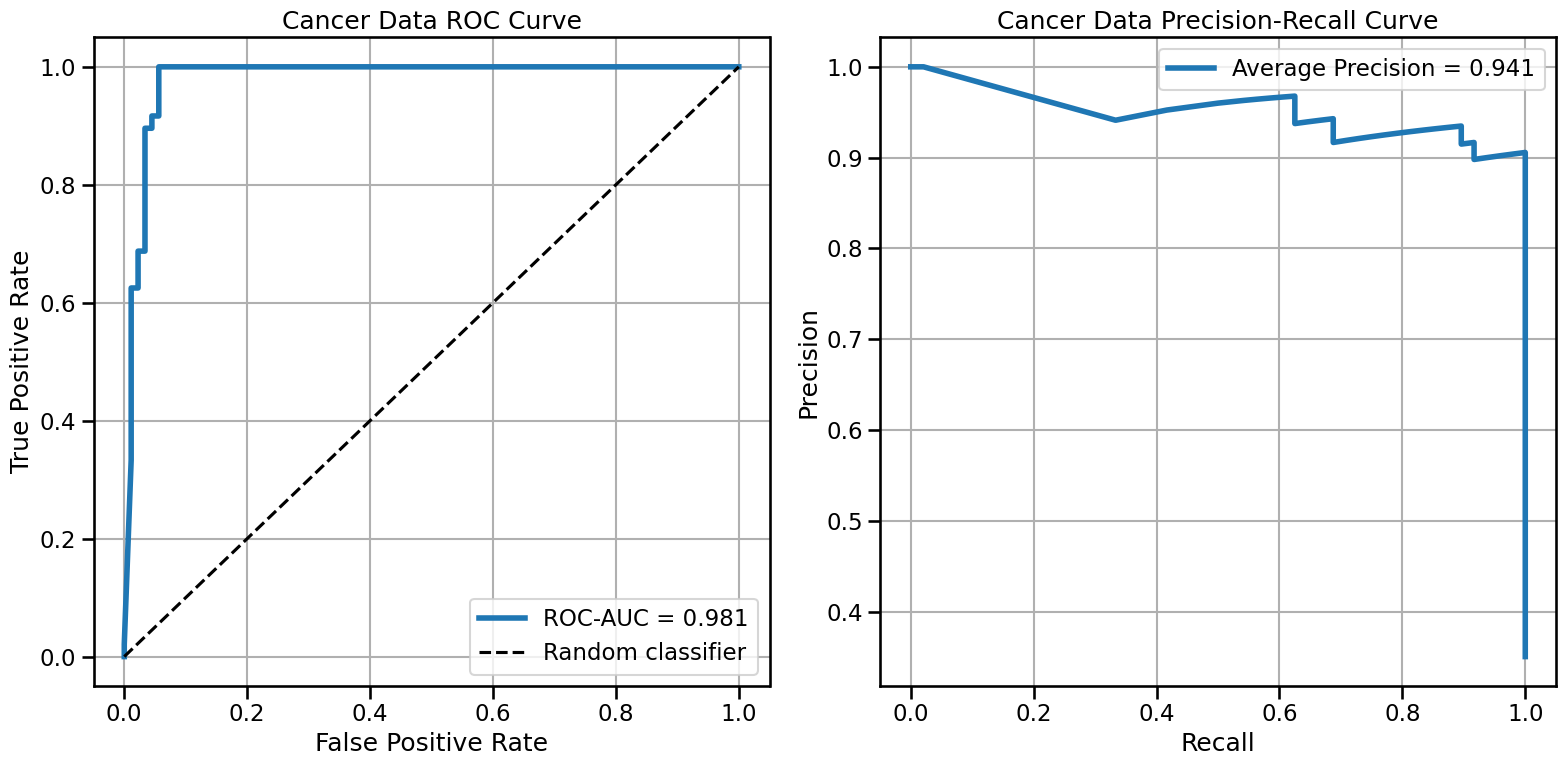

In [ ]:
bag_cancer = search.best_estimator_
y_pred = bag_cancer.predict(X_test)

sns.set_context("talk")
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=bag_cancer.classes_
)
disp.plot()
plt.title("Cancer Data Confusion Matrix")
plt.show()

# In this dataset, class 4 represents malignant samples.
positive_class = 4
y_score = bag_cancer.predict_proba(X_test)[
    :, list(bag_cancer.classes_).index(positive_class)
]
y_test_binary = (y_test == positive_class).astype(int)

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

fpr, tpr, _ = metrics.roc_curve(y_test_binary, y_score)
roc_auc = metrics.roc_auc_score(y_test_binary, y_score)
axes[0].plot(fpr, tpr, linewidth=4, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot(
    [0, 1], [0, 1], linestyle="--", color="black", label="Random classifier"
)
axes[0].set(
    title="Cancer Data ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
axes[0].legend()
axes[0].grid(True)

precision, recall, _ = metrics.precision_recall_curve(y_test_binary, y_score)
avg_precision = metrics.average_precision_score(y_test_binary, y_score)
axes[1].plot(
    recall,
    precision,
    linewidth=4,
    label=f"Average Precision = {avg_precision:.3f}",
)
axes[1].set(
    title="Cancer Data Precision-Recall Curve",
    xlabel="Recall",
    ylabel="Precision",
)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Findings:**

The tuned Bagging model performs well on the cancer data, with **0.949 test accuracy** and **0.995 training accuracy**. The confusion matrix shows only a small number of mistakes: **5 benign samples were predicted as malignant**, and **2 malignant samples were predicted as benign**. The ROC-AUC is about **0.981**, which shows strong separation between the two cancer classes.


#### **Feature Importance**

Average the feature importances across all decision trees in the best Bagging model.


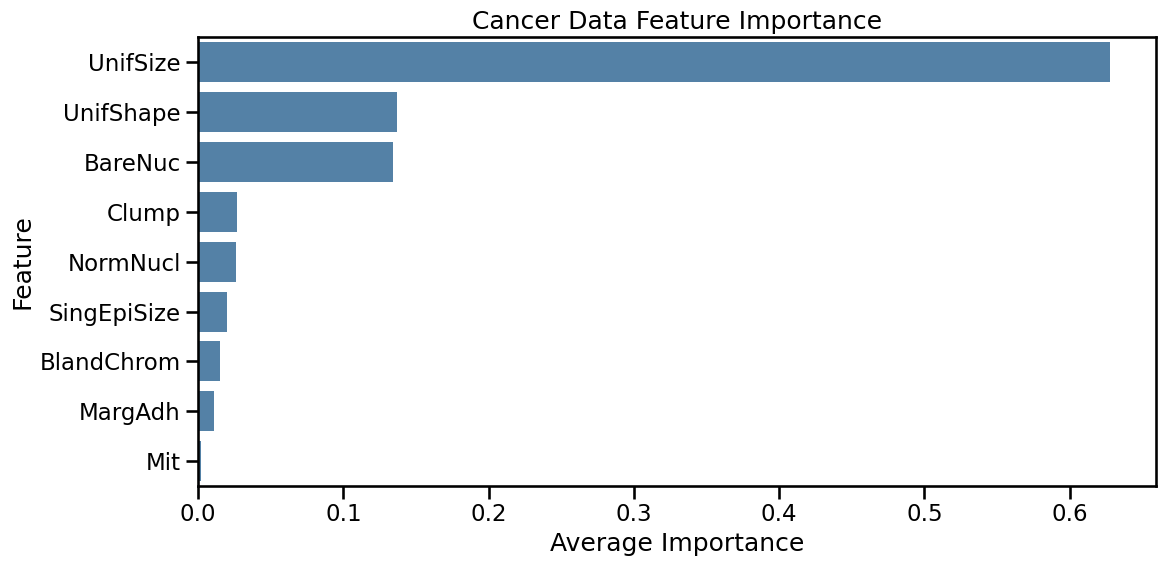

In [ ]:
feature_imp = np.mean(
    [tree.feature_importances_ for tree in bag_cancer.estimators_], axis=0
)

feature_imp = pd.Series(feature_imp, index=X_train.columns).sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color="steelblue")
ax.set(
    title="Cancer Data Feature Importance",
    xlabel="Average Importance",
    ylabel="Feature",
)
plt.tight_layout()
plt.show()

**Findings:**

The feature-importance plot shows that **Uniformity of Cell Size** is the strongest predictor by far. **Uniformity of Cell Shape** and **Bare Nuclei** are also important. These results suggest that differences in cell size, cell shape, and nuclei are the main patterns the Bagging model uses to classify cancer samples.


### **Exercise: Course of Treatment Data**

The same course of treatment dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.5.


In [ ]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv",
    delimiter=",",
)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


Lets create the X and y for our dataset


In [ ]:
X = df[["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]].values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [242]:
y = df["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

Now lets use a `LabelEncoder` to turn categorical features into numerical


In [ ]:
le_sex = preprocessing.LabelEncoder()
le_sex.fit(["F", "M"])
X[:, 1] = le_sex.transform(X[:, 1])

In [ ]:
le_BP = preprocessing.LabelEncoder()
le_BP.fit(["LOW", "NORMAL", "HIGH"])
X[:, 2] = le_BP.transform(X[:, 2])

In [ ]:
le_Chol = preprocessing.LabelEncoder()
le_Chol.fit(["NORMAL", "HIGH"])
X[:, 3] = le_Chol.transform(X[:, 3])

In [246]:
X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

Split the data into training and testing data with a 80/20 split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=4
)
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (160, 5) (160,)
Test set: (40, 5) (40,)


Using the same parameter grid as before


In [ ]:
param_grid = {
    "n_estimators": [2 * n + 1 for n in range(20)],
    "estimator__max_depth": [2 * n + 1 for n in range(10)],
}

Create a `BaggingClassifier` object called `Bag` with the `estimator` set to a `DecisionTreeClassifier` object where `random_state` = 0 and `bootstrap` = True


In [ ]:
# add your code below
Bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(), random_state=0, bootstrap=True
)

Create a `StratifiedKFold` object for cross-validation. Then create `GridSearchCV` object called `search` with the `estimator` set to `Bag`, `param_grid` set to `param_grid`, `scoring` set to `accuracy`, and `cv` set to the stratified cross-validation object.


In [ ]:
# add your code below
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

search = GridSearchCV(
    estimator=Bag, param_grid=param_grid, scoring="accuracy", cv=cv
)

Fit the `GridSearchCV` object to our `X_train` and `y_train` data


In [251]:
# add your code below
search.fit(X_train, y_train)

,estimator,BaggingClassi...andom_state=0)
,param_grid,"{'estimator__max_depth': [1, 3, ...], 'n_estimators': [1, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


After using `fit` we can see the best score and parameters


In [252]:
search.best_score_

0.99375

In [253]:
search.best_params_

{'estimator__max_depth': 5, 'n_estimators': 1}

In [254]:
print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 1.0, 'train Accuracy': 1.0}


Below we can see a graph of testing and training accuracy holding the max_depth of the estimator at 10 and varying the number of estimators. We can see that it is extremely close to the accuracy of the best_estimator we found using GridSearchCV


100%|██████████| 20/20 [00:27<00:00,  1.40s/it]


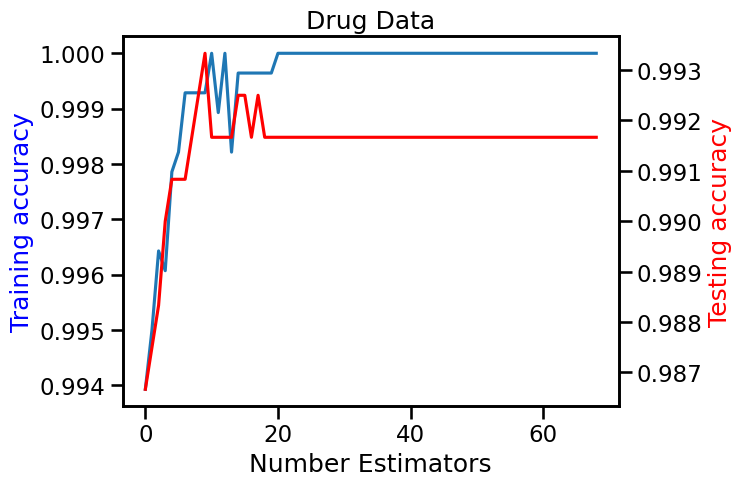

In [257]:
get_accuracy_bag(X, y, "Drug Data")

#### **Evaluation**

Evaluate the best Bagging model from GridSearchCV using a confusion matrix and one-vs-rest ROC/precision-recall curves.


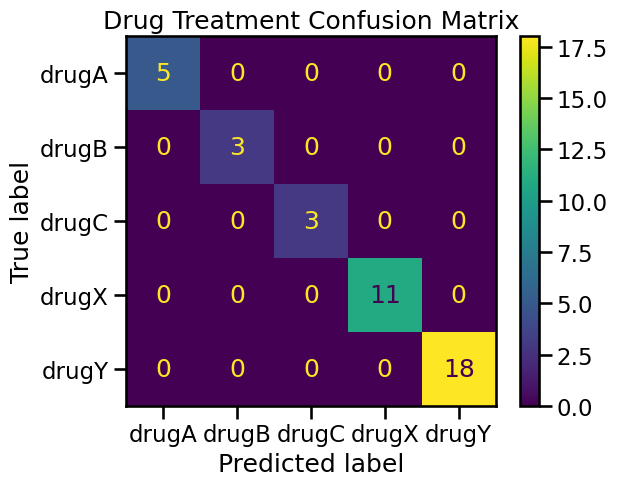

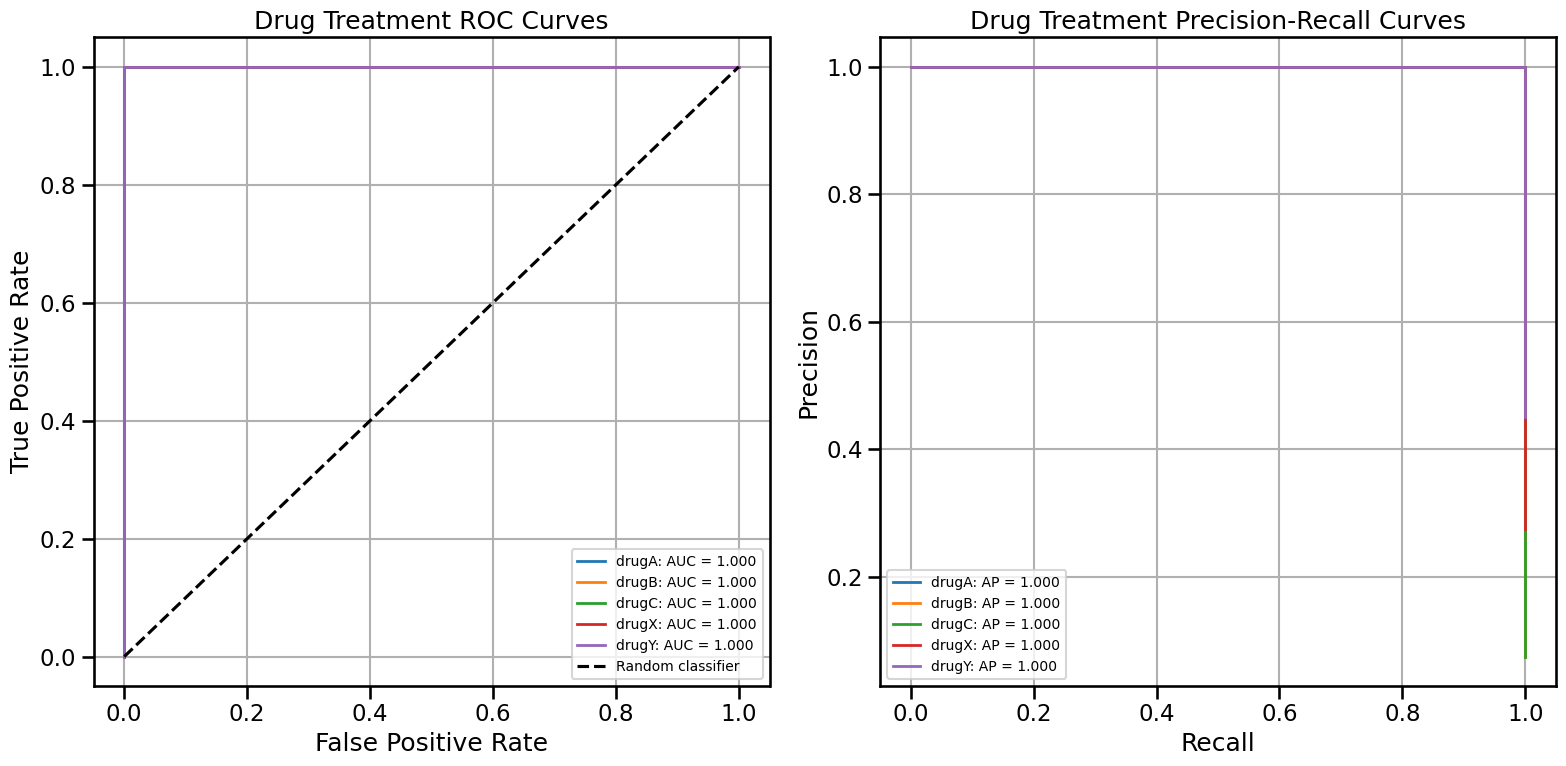

In [ ]:
bag_drug = search.best_estimator_
y_pred = bag_drug.predict(X_test)

sns.set_context("talk")
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=bag_drug.classes_
)
disp.plot()
plt.title("Drug Treatment Confusion Matrix")
plt.show()

classes = bag_drug.classes_
y_score = bag_drug.predict_proba(X_test)
y_test_binary = pd.get_dummies(pd.Categorical(y_test, categories=classes))

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = metrics.roc_curve(y_test_binary.iloc[:, i], y_score[:, i])
    roc_auc = metrics.roc_auc_score(y_test_binary.iloc[:, i], y_score[:, i])
    axes[0].plot(
        fpr, tpr, linewidth=2, label=f"{class_name}: AUC = {roc_auc:.3f}"
    )

    precision, recall, _ = metrics.precision_recall_curve(
        y_test_binary.iloc[:, i], y_score[:, i]
    )
    avg_precision = metrics.average_precision_score(
        y_test_binary.iloc[:, i], y_score[:, i]
    )
    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_name}: AP = {avg_precision:.3f}",
    )

axes[0].plot(
    [0, 1], [0, 1], linestyle="--", color="black", label="Random classifier"
)
axes[0].set(
    title="Drug Treatment ROC Curves",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
axes[0].legend(fontsize=10)
axes[0].grid(True)

axes[1].set(
    title="Drug Treatment Precision-Recall Curves",
    xlabel="Recall",
    ylabel="Precision",
)
axes[1].legend(fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Findings:**

The Bagging model reaches **1.00 training accuracy** and **1.00 test accuracy** on the drug treatment data. The confusion matrix shows that every test patient was assigned to the correct drug class. The ROC and precision-recall curves should also look nearly perfect for each drug class. Because this dataset is small, the perfect score should be interpreted carefully and tested again on more data.


#### **Feature Importance**

Average the feature importances across all decision trees in the best Bagging model.


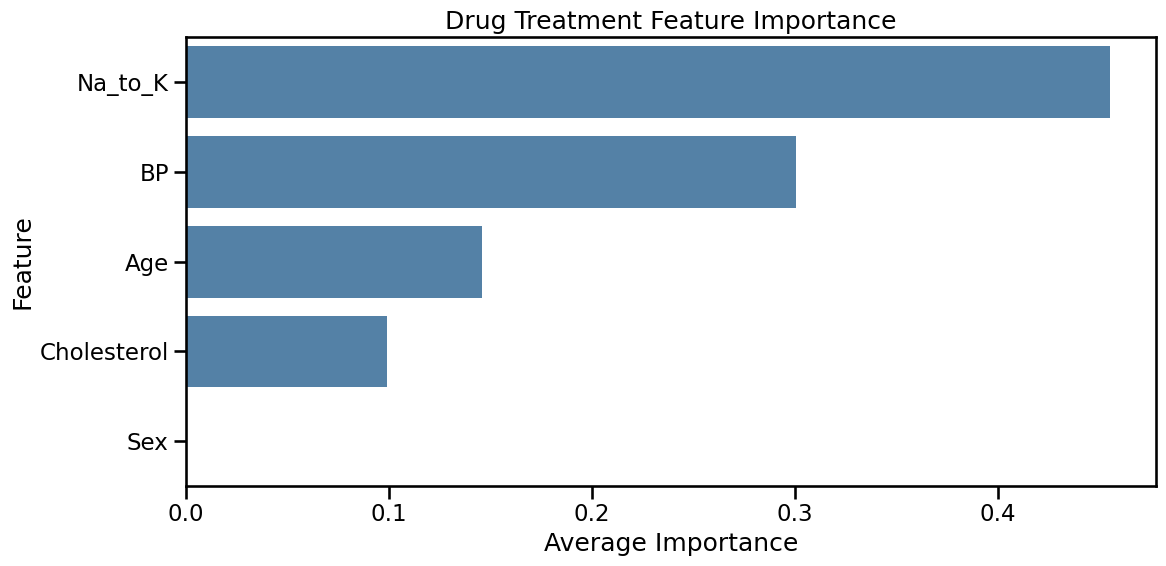

In [ ]:
feature_names = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]

feature_imp = np.mean(
    [tree.feature_importances_ for tree in bag_drug.estimators_], axis=0
)

feature_imp = pd.Series(feature_imp, index=feature_names).sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color="steelblue")
ax.set(
    title="Drug Treatment Feature Importance",
    xlabel="Average Importance",
    ylabel="Feature",
)
plt.tight_layout()
plt.show()

**Findings:**

The most important feature for predicting drug treatment is **Na_to_K**. **Blood Pressure** is the second most important feature, followed by **Age** and **Cholesterol**. **Sex** has little or no importance in this fitted model, so it does not appear to help the model choose the drug class for this dataset.


## **Author**

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>, Su Wu

### **Other Contributors**

<a href="https://www.linkedin.com/in/richard-ye/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Richard Ye</a>

## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>

<!--## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2022-01-19        | 0.1     | Joseph Santarcangelo | Created Lab Template |
| 2022-05-03        | 0.2     | Richard Ye           | QA pass              |--!>



